In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import sys
warnings.filterwarnings('ignore')
sys.path.append('../..')
from src.utils.config import PROCESSED_DIR
plt.style.use('seaborn-v0_8-darkgrid')
# Load AAPL feature matrix as primary example
df = pd.read_csv(PROCESSED_DIR / 'features/AAPL_features.csv',
                 index_col=0, parse_dates=True)
print(f'Shape: {df.shape}')
print(f'Features: {len(df.columns)}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'\nFirst 5 feature names:')
print(list(df.columns[:5]))

Shape: (2508, 47)
Features: 47
Date range: 2016-01-04 00:00:00 to 2025-12-22 00:00:00

First 5 feature names:
['Open', 'High', 'Low', 'Close', 'Volume']


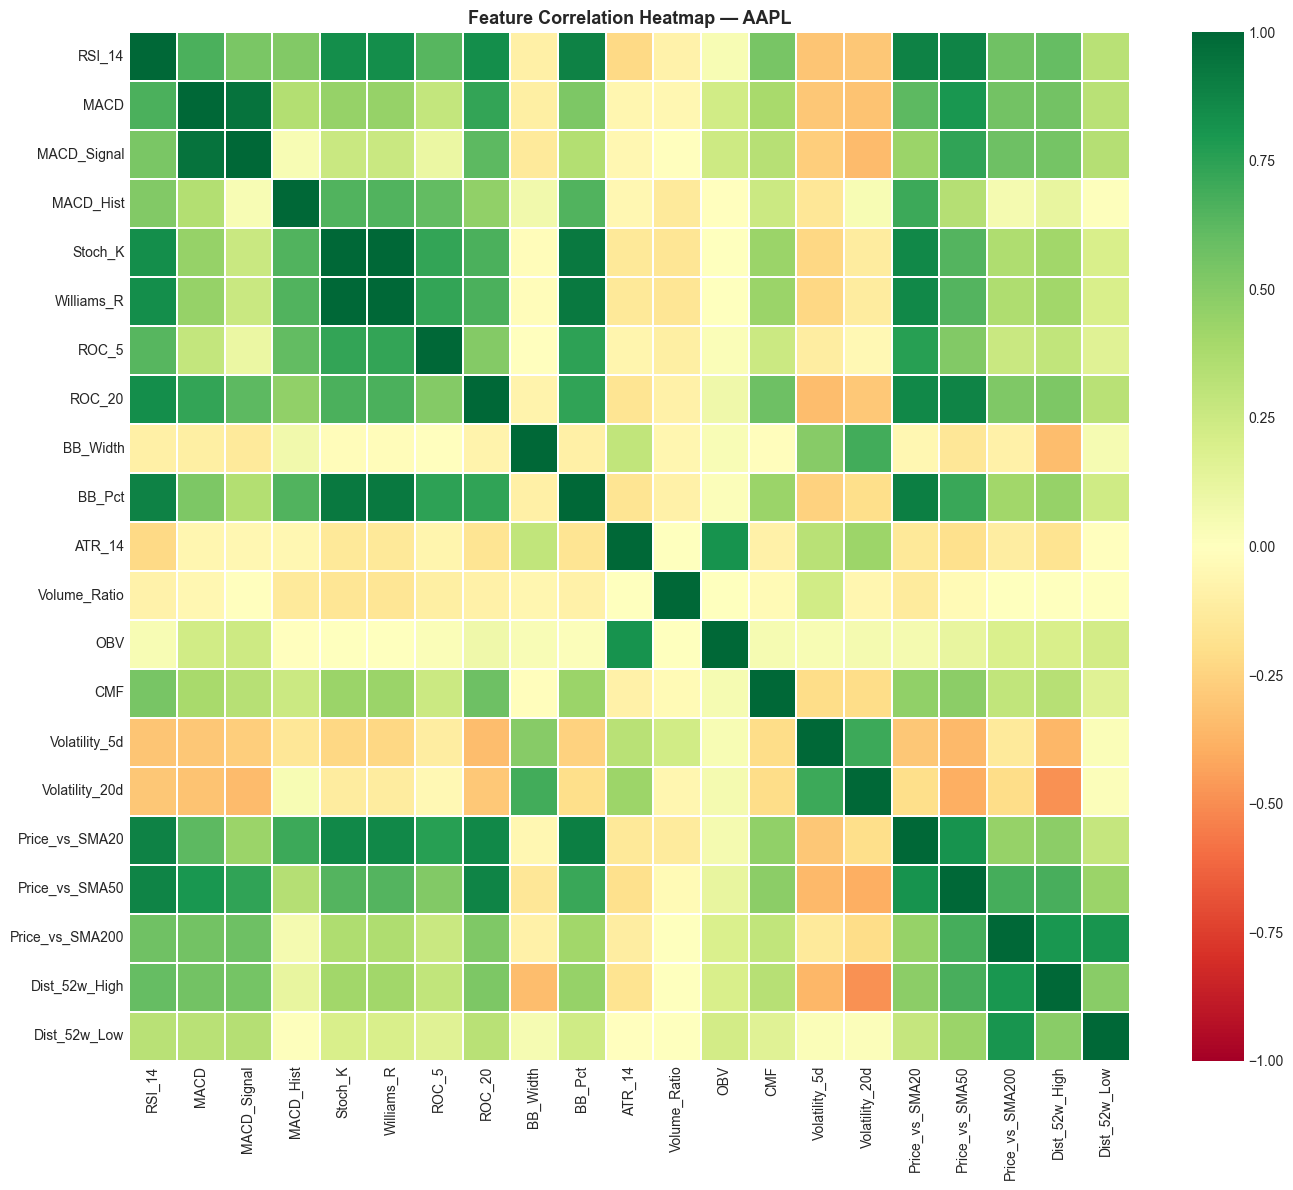

Highly correlated pairs (|r| > 0.85):
 Feature 1      Feature 2  Correlation
    RSI_14         BB_Pct        0.890
    RSI_14 Price_vs_SMA20        0.883
    RSI_14 Price_vs_SMA50        0.879
      MACD    MACD_Signal        0.951
   Stoch_K     Williams_R        1.000
   Stoch_K         BB_Pct        0.926
   Stoch_K Price_vs_SMA20        0.864
Williams_R         BB_Pct        0.926
Williams_R Price_vs_SMA20        0.864
    ROC_20 Price_vs_SMA20        0.859
    ROC_20 Price_vs_SMA50        0.877
    BB_Pct Price_vs_SMA20        0.904


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select key technical features for correlation analysis
feature_cols = [
    'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'Stoch_K', 'Williams_R', 'ROC_5', 'ROC_20',
    'BB_Width', 'BB_Pct', 'ATR_14',
    'Volume_Ratio', 'OBV', 'CMF',
    'Volatility_5d', 'Volatility_20d',
    'Price_vs_SMA20', 'Price_vs_SMA50', 'Price_vs_SMA200',
    'Dist_52w_High', 'Dist_52w_Low'
]

# Ensure no missing values before correlation
feat_df = df[feature_cols].dropna()
corr_feat = feat_df.corr()

# Visualize the Feature Heatmap
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr_feat,
    annot=False,  # Set to False because there are many columns
    cmap='RdYlGn',
    vmin=-1, 
    vmax=1,
    center=0,
    ax=ax,
    linewidths=0.3
)

ax.set_title('Feature Correlation Heatmap — AAPL', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/eda/05_feature_correlation.png', dpi=150)
plt.show()

# Finding highly correlated pairs to potentially remove (Multicollinearity Check)
high_corr = []
for i in range(len(corr_feat.columns)):
    for j in range(i + 1, len(corr_feat.columns)):
        c = abs(corr_feat.iloc[i, j])
        if c > 0.85:
            high_corr.append({
                'Feature 1': corr_feat.columns[i],
                'Feature 2': corr_feat.columns[j],
                'Correlation': round(corr_feat.iloc[i, j], 3)
            })

print(f'Highly correlated pairs (|r| > 0.85):')
if high_corr:
    print(pd.DataFrame(high_corr).to_string(index=False))
else:
    print('None found')

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.append('../..')
from src.utils.config import PROCESSED_DIR

# Load X_train first — this was missing
X_train = pd.read_csv(PROCESSED_DIR / 'splits/AAPL/X_train.csv',
                      index_col=0, parse_dates=True)

print(f'X_train loaded: {X_train.shape}')
print(f'Columns available: {len(X_train.columns)}')

X_train loaded: (1762, 43)
Columns available: 43


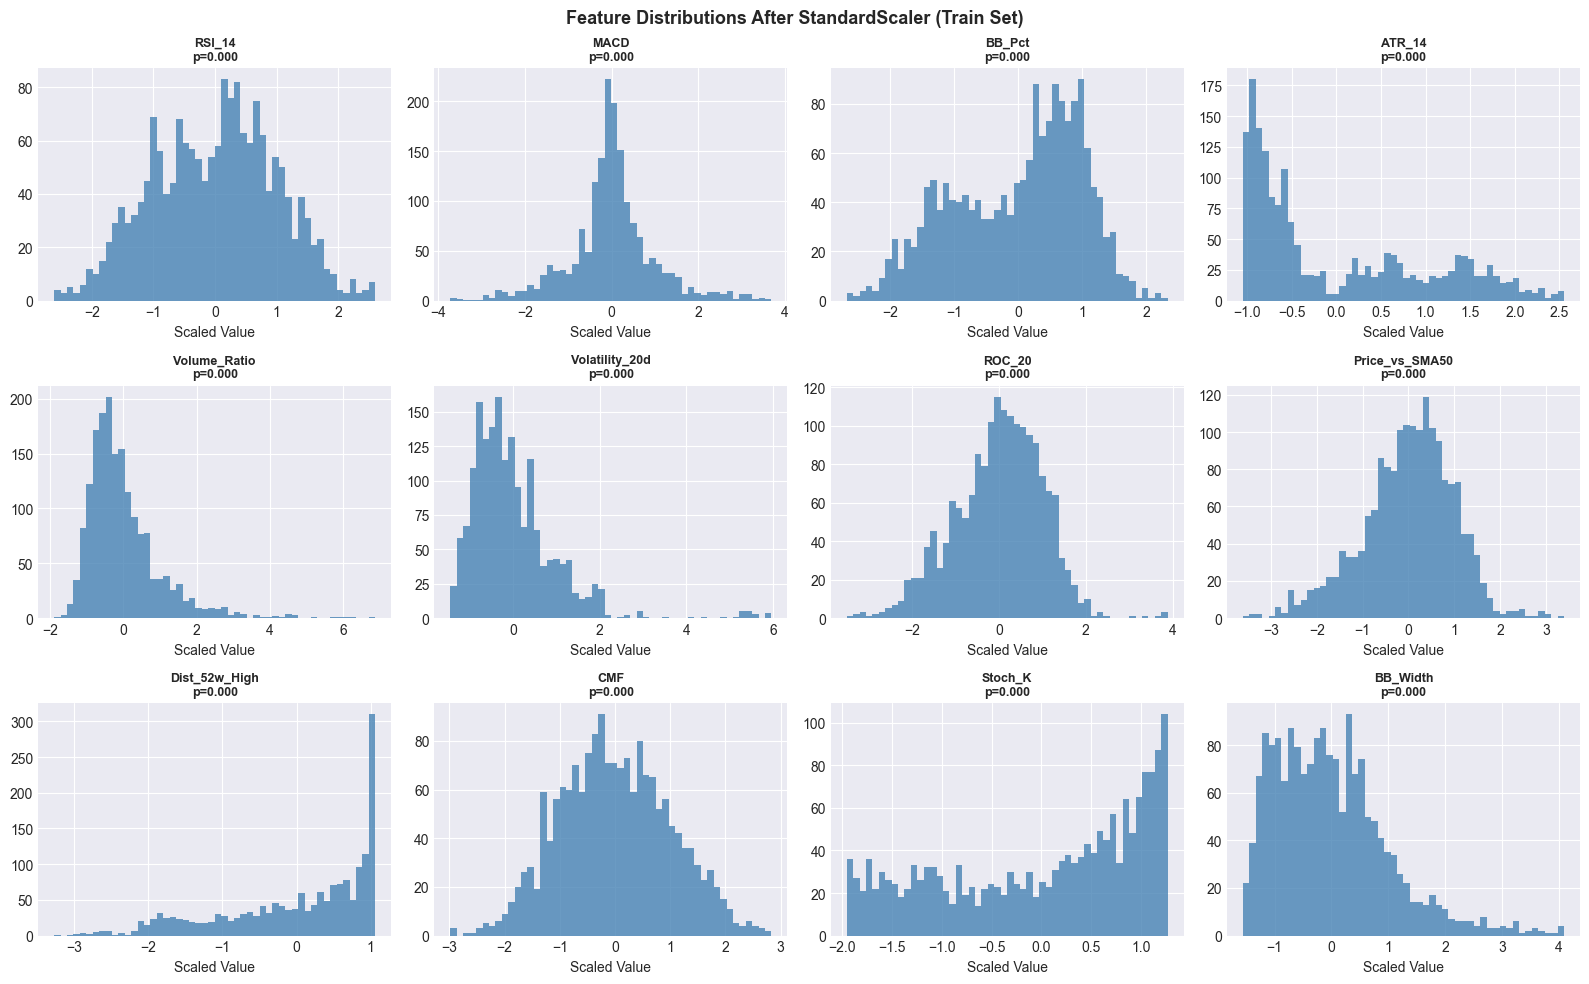

In [7]:
key_features = [
    'RSI_14', 'MACD', 'BB_Pct', 'ATR_14',
    'Volume_Ratio', 'Volatility_20d', 'ROC_20',
    'Price_vs_SMA50', 'Dist_52w_High', 'CMF',
    'Stoch_K', 'BB_Width'
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    if feat in X_train.columns:
        data = X_train[feat].dropna()
        axes[i].hist(data, bins=50, color='steelblue',
                     edgecolor='none', alpha=0.8)
        axes[i].set_xlabel('Scaled Value')
        _, p_val = stats.normaltest(data)
        axes[i].set_title(f'{feat}\np={p_val:.3f}',
                          fontsize=9, fontweight='bold')

plt.suptitle('Feature Distributions After StandardScaler (Train Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/eda/06_feature_distributions.png', dpi=150)
plt.show()

X_train index type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
y_train index type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
Common dates after fix: 1762

Up days:   1037
Down days: 725


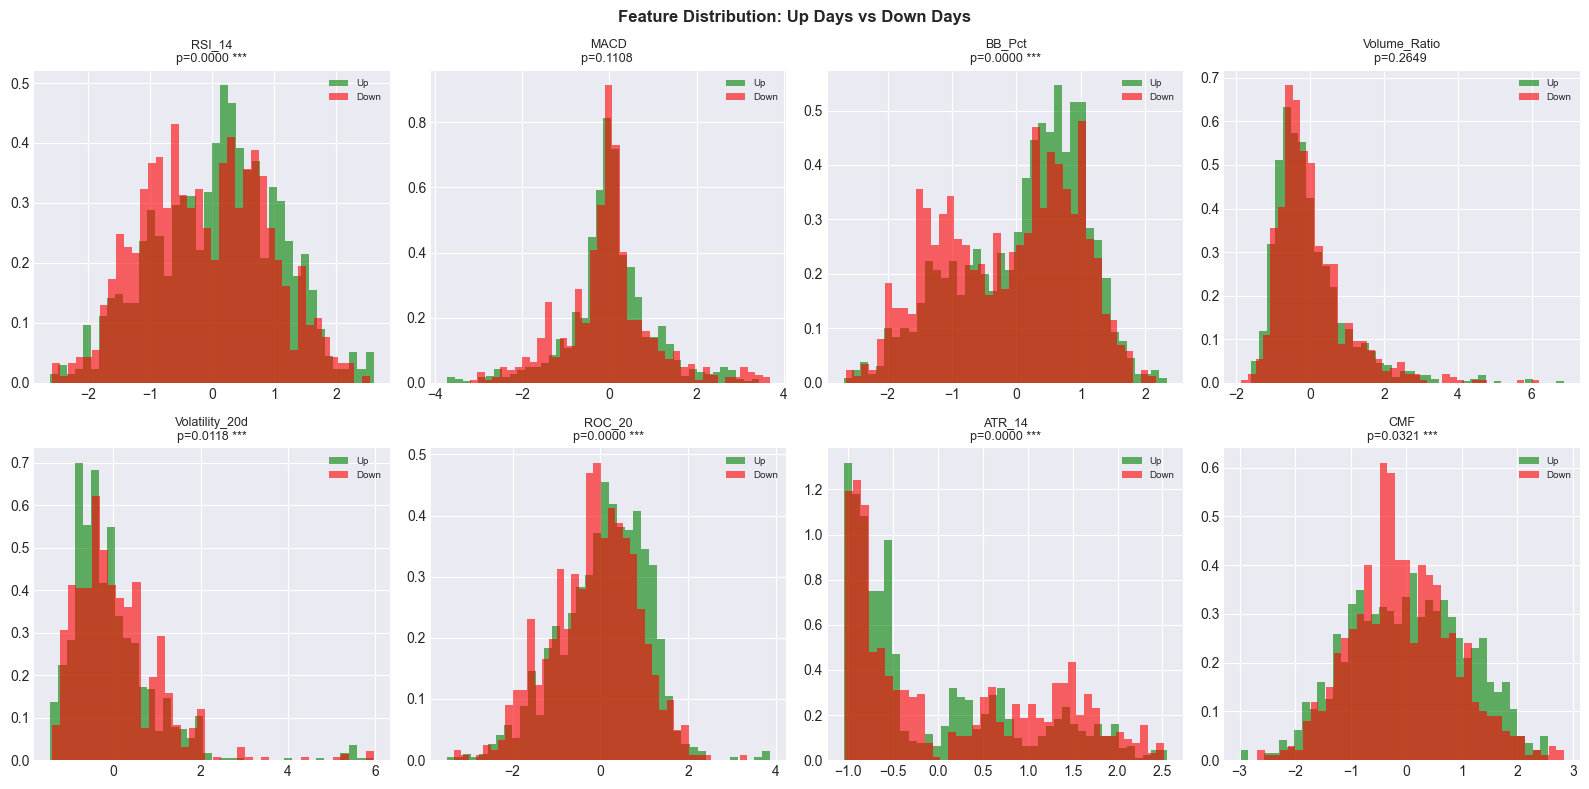


Feature Significance Summary:
       Feature  Up Mean  Down Mean  p-value  Significant
        RSI_14   0.0884    -0.1264   0.0000         True
          MACD   0.0322    -0.0461   0.1108        False
        BB_Pct   0.1055    -0.1509   0.0000         True
  Volume_Ratio  -0.0220     0.0315   0.2649        False
Volatility_20d  -0.0500     0.0716   0.0118         True
        ROC_20   0.0899    -0.1286   0.0000         True
        ATR_14  -0.1060     0.1517   0.0000         True
           CMF   0.0417    -0.0596   0.0321         True

Significant features (p < 0.05):
       Feature  p-value
        RSI_14   0.0000
        BB_Pct   0.0000
Volatility_20d   0.0118
        ROC_20   0.0000
        ATR_14   0.0000
           CMF   0.0321


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.append('../..')
from scipy import stats
from src.utils.config import PROCESSED_DIR

# Load data
X_train = pd.read_csv(PROCESSED_DIR / 'splits/AAPL/X_train.csv',
                      index_col=0, parse_dates=True)

y_train = pd.read_csv(PROCESSED_DIR / 'splits/AAPL/y_train.csv',
                      index_col=0).squeeze()
y_train.index = pd.to_datetime(y_train.index)
print(f'X_train index type: {type(X_train.index[0])}')
print(f'y_train index type: {type(y_train.index[0])}')
print(f'Common dates after fix: {len(X_train.index.intersection(y_train.index))}')

# Combine
train_df = X_train.copy()
train_df['Target'] = y_train

# Split up and down days
up_days   = train_df[train_df['Target'] == 1]
down_days = train_df[train_df['Target'] == 0]

print(f'\nUp days:   {len(up_days)}')
print(f'Down days: {len(down_days)}')

# Key features
key_features = ['RSI_14', 'MACD', 'BB_Pct', 'Volume_Ratio',
                'Volatility_20d', 'ROC_20', 'ATR_14', 'CMF']
available = [f for f in key_features if f in X_train.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

results = []

for i, feat in enumerate(available):
    up_vals   = up_days[feat].dropna().values
    down_vals = down_days[feat].dropna().values

    axes[i].hist(up_vals,   bins=40, alpha=0.6,
                 color='green', label='Up',   density=True)
    axes[i].hist(down_vals, bins=40, alpha=0.6,
                 color='red',   label='Down', density=True)

    t_stat, p_val = stats.ttest_ind(up_vals, down_vals, equal_var=False)

    sig = '***' if p_val < 0.05 else ''
    axes[i].set_title(f'{feat}\np={p_val:.4f} {sig}', fontsize=9)
    axes[i].legend(fontsize=7)

    results.append({
        'Feature':     feat,
        'Up Mean':     round(float(up_vals.mean()),   4),
        'Down Mean':   round(float(down_vals.mean()), 4),
        'p-value':     round(float(p_val),            4),
        'Significant': bool(p_val < 0.05)
    })

plt.suptitle('Feature Distribution: Up Days vs Down Days',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/eda/07_feature_vs_target.png', dpi=150)
plt.show()

# Results table
print('\nFeature Significance Summary:')
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print('\nSignificant features (p < 0.05):')
sig = results_df[results_df['Significant'] == True]
print(sig[['Feature','p-value']].to_string(index=False)
      if len(sig) > 0 else 'None at p < 0.05')

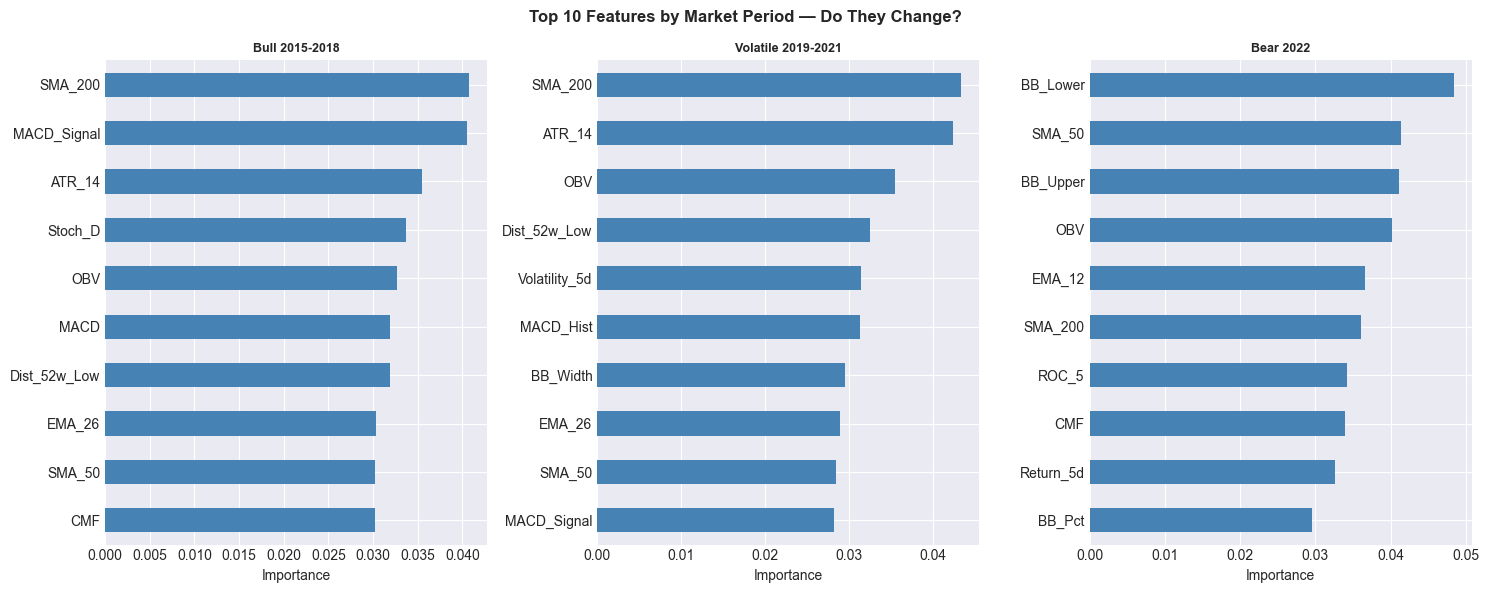

In [12]:
from sklearn.ensemble import RandomForestClassifier

X_train = pd.read_csv(PROCESSED_DIR / 'splits/AAPL/X_train.csv',
                      index_col=0, parse_dates=True)
y_train = pd.read_csv(PROCESSED_DIR / 'splits/AAPL/y_train.csv',
                      index_col=0).squeeze()

# Split training data into 3 periods
periods = {
    'Bull 2015-2018': ('2015-01-01', '2018-12-31'),
    'Volatile 2019-2021': ('2019-01-01', '2021-12-31'),
    'Bear 2022': ('2022-01-01', '2022-12-31'),
}

importance_by_period = {}

for period_name, (start, end) in periods.items():
    X_p = X_train.loc[start:end]
    y_p = y_train.loc[start:end]
    
    if len(X_p) < 50:
        continue
        
    rf = RandomForestClassifier(n_estimators=50, random_state=42)
    rf.fit(X_p, y_p)
    
    importance_by_period[period_name] = pd.Series(
        rf.feature_importances_,
        index=X_p.columns
    ).nlargest(10)

# Plot side by side
fig, axes = plt.subplots(1, len(importance_by_period),
                          figsize=(15, 6))

for ax, (period, imp) in zip(axes, importance_by_period.items()):
    imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(period, fontsize=9, fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Top 10 Features by Market Period — Do They Change?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/eda/08_rolling_importance.png', dpi=150)
plt.show()